# DATATHON 2026 — THE GRIDBREAKER
**Hosted by:** VinTelligence - VinUniversity Data Science & AI Club

---

## THÔNG TIN NHÓM
- **Tên đội thi**: Last Dance
- **Mã đội thi**: kVmzJpHWUFT6mv82wG4U
- **Thành viên**: 

| STT | Họ và tên        |  Vai trò   | Email |
| --- | ---------------- | ---------- | ----- |
| 1   | Bùi Lê Khôi      | Đội trưởng |       |
| 2   | Nguyễn Hà Anh    | Thành viên |       |
| 3   | Bùi Công Mậu     | Thành viên |       |
| 4   | Thái Hữu Thọ     | Thành viên |       |

---

## GIỚI THIỆU FILE NOTEBOOK

- **Mục đích**: Phân tích EDA theo 4 cấp độ (Descriptive → Diagnostic → Predictive → Prescriptive)

- **Nội dung trong file**:
    - Cấp 1 (Descriptive): Doanh thu thực tế theo tháng, cơ cấu khách hàng.
    - Cấp 2 (Diagnostic): Tương quan rating–return rate, correlation heatmap, phân tích sản phẩm.
    - Cấp 3 (Predictive): Phân cụm RFM với Elbow Method + Silhouette Score, Cohort Retention Analysis.
    - Cấp 4 (Prescriptive): Đưa ra các quyết định cụ thể.

---

Bài làm được trình bày từ sau dòng này.

---
---

### Import các libs và dependencies

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl as pxl
import seaborn as sns
import statsmodels.api as sm
import datetime as dt
import os 

from datetime import timedelta
from scipy import stats
from math import sqrt

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, pairwise_distances, silhouette_score, precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import silhouette_score


import warnings
warnings.filterwarnings("ignore")

# Ensure plots appear in the notebook
%matplotlib inline

# Print last updated timestamp
import time
print(f"Cập nhật lần cuối vào thời điểm {time.asctime()}")

Cập nhật lần cuối vào thời điểm Fri May  1 09:04:45 2026


In [4]:
DATA_PATH = '../data/processed/'

orders    = pd.read_csv(os.path.join(DATA_PATH, 'enriched_orders.csv'),   parse_dates=['order_date'])
customers = pd.read_csv(os.path.join(DATA_PATH, 'enriched_customers.csv'))
products  = pd.read_csv(os.path.join(DATA_PATH, 'enriched_products.csv'))
payments  = pd.read_csv(os.path.join(DATA_PATH, 'payments.csv'))
raw_customers = pd.read_csv(os.path.join(DATA_PATH, 'customers.csv'),     parse_dates=['signup_date'])

print('Dữ liệu đã sẵn sàng cho phân tích.')
for name, df in [('orders', orders), ('customers', customers), ('products', products)]:
    print(f'  {name:<12}: {df.shape[0]:>7,} rows, {df.shape[1]} cols')

Dữ liệu đã sẵn sàng cho phân tích.
  orders      : 646,945 rows, 14 cols
  customers   :  90,246 rows, 10 cols
  products    :   2,412 rows, 13 cols



## PHÂN TÍCH MÔ TẢ (DESCRIPTIVE)
**Câu hỏi: Chuyện gì đã xảy ra?**

> Mục tiêu: Hiểu bức tranh tổng quan về **doanh thu thực tế**, **số đơn hàng**, và **cơ cấu khách hàng**.

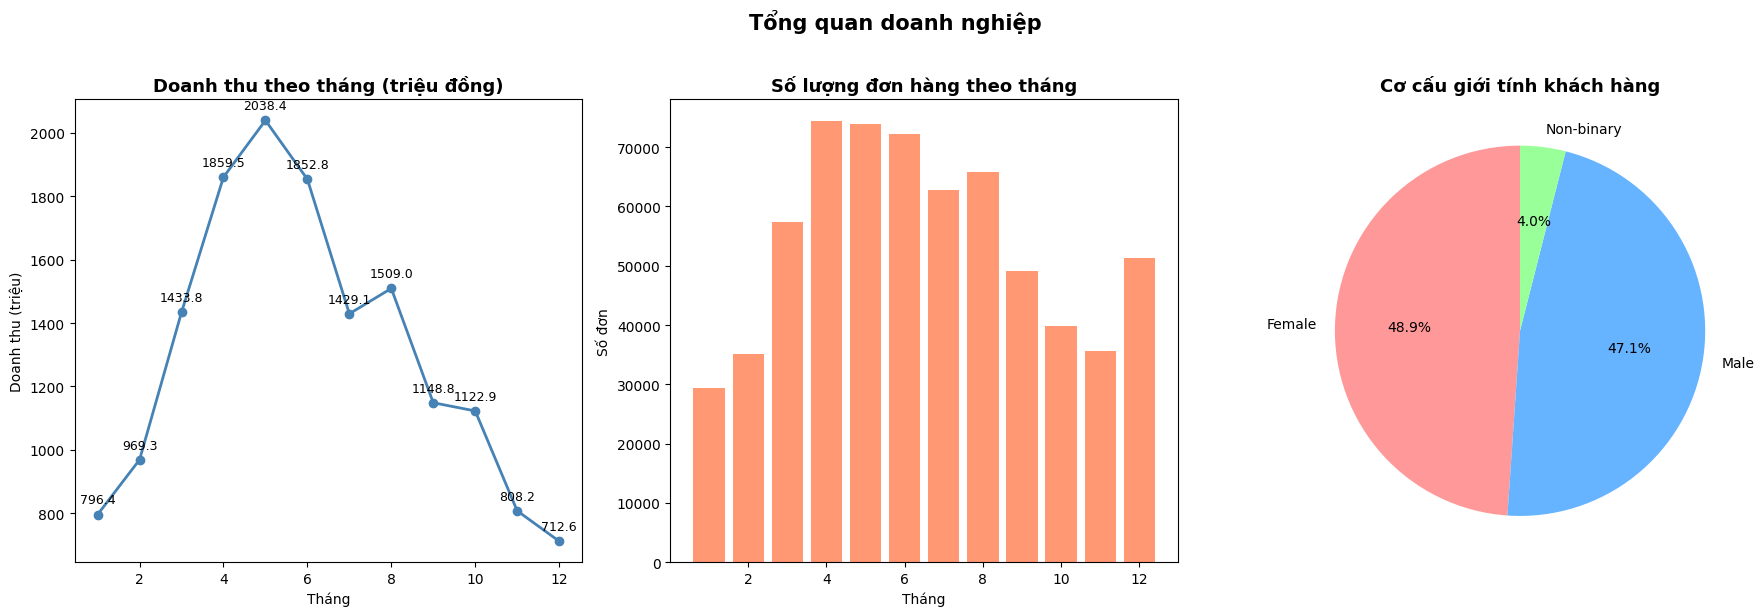

In [29]:
# Join với payments để tính doanh thu THỰC TẾ thay vì chỉ đếm số đơn
monthly_agg = (
    orders
    .merge(payments[['order_id', 'payment_value']], on='order_id', how='left')
    .groupby('order_month')
    .agg(
        order_count = ('order_id',       'nunique'),
        revenue     = ('payment_value',  'sum'),
        avg_order_value = ('payment_value', 'mean')
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Doanh thu theo tháng
axes[0].plot(monthly_agg['order_month'], monthly_agg['revenue'] / 1e6,
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Doanh thu theo tháng (triệu đồng)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tháng'); axes[0].set_ylabel('Doanh thu (triệu)')
for x, y in zip(monthly_agg['order_month'], monthly_agg['revenue'] / 1e6):
    axes[0].annotate(f'{y:.1f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

# 2. Số đơn hàng theo tháng
axes[1].bar(monthly_agg['order_month'], monthly_agg['order_count'],
            color='coral', alpha=0.8)
axes[1].set_title('Số lượng đơn hàng theo tháng', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tháng'); axes[1].set_ylabel('Số đơn')

# 3. Cơ cấu giới tính
gender_counts = raw_customers['gender'].value_counts()
axes[2].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=['#ff9999', '#66b3ff', '#99ff99'],
            startangle=90)
axes[2].set_title('Cơ cấu giới tính khách hàng', fontsize=13, fontweight='bold')

plt.suptitle('Tổng quan doanh nghiệp', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



- Doanh thu tăng mạnh từ tháng 1 và đạt đỉnh vào khoảng tháng 5.
- Sau tháng 6, doanh thu bắt đầu giảm dần, đặc biệt giảm mạnh vào tháng 11–12.
- Số lượng đơn hàng có xu hướng tương tự: tăng trưởng mạnh đầu năm, đạt đỉnh giữa năm và giảm về cuối năm.
- Không có sự khác biệt quá rõ ràng giữa các nhóm giới tính với nhau.
- Doanh nghiệp có **tính mùa vụ rõ rệt**, với giai đoạn cao điểm rơi vào giữa năm.
- Sự sụt giảm cả về doanh thu và số lượng đơn hàng cuối năm cho thấy:
  - Nhu cầu thị trường giảm.
  - Khả năng giữ chân khách hàng chưa tốt.
  - Thiếu các chiến dịch kích cầu giai đoạn cuối năm.

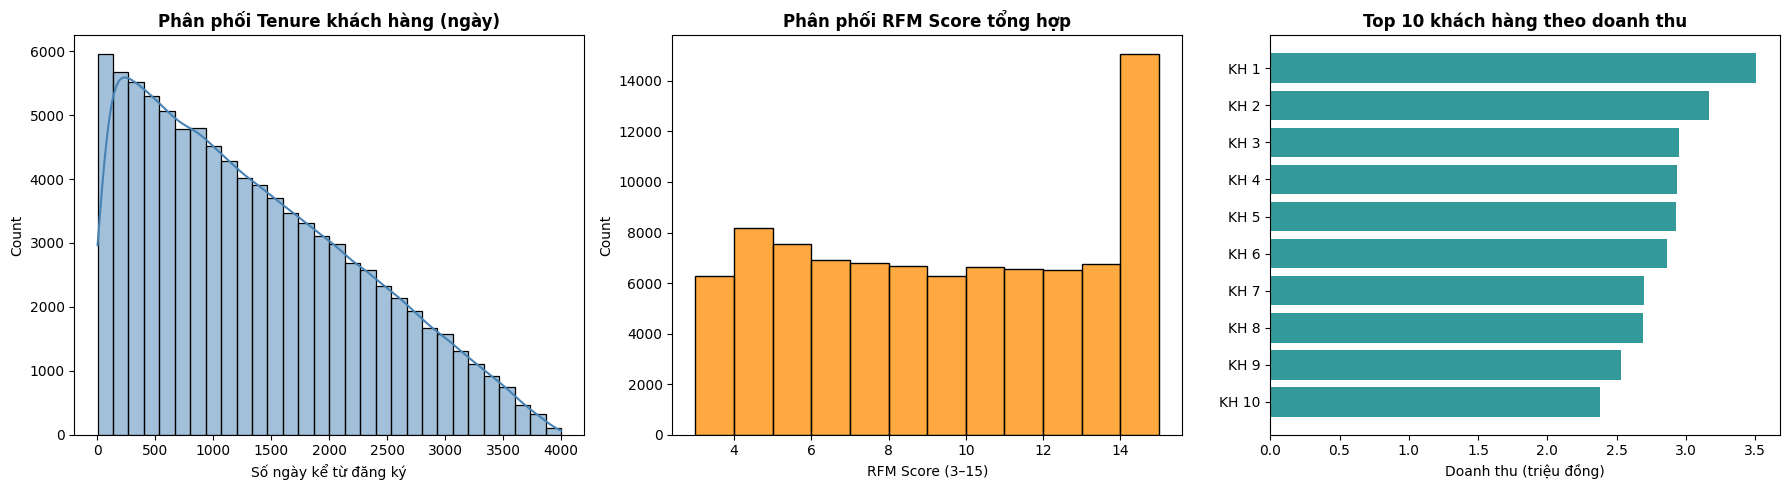

In [17]:
# Phân phối Tenure và RFM Score
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(customers['tenure_days'], bins=30, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Phân phối Tenure khách hàng (ngày)', fontweight='bold')
axes[0].set_xlabel('Số ngày kể từ đăng ký')

sns.histplot(customers['RFM_score'], bins=12, ax=axes[1], color='darkorange', kde=False)
axes[1].set_title('Phân phối RFM Score tổng hợp', fontweight='bold')
axes[1].set_xlabel('RFM Score (3–15)')

# Top 10 khách hàng theo monetary
top_customers = customers.nlargest(10, 'monetary')[['customer_id', 'monetary', 'frequency', 'RFM_score']]
axes[2].barh(range(10), top_customers['monetary'] / 1e6, color='teal', alpha=0.8)
axes[2].set_yticks(range(10))
axes[2].set_yticklabels([f'KH {i+1}' for i in range(10)])
axes[2].set_title('Top 10 khách hàng theo doanh thu', fontweight='bold')
axes[2].set_xlabel('Doanh thu (triệu đồng)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


- Phân phối lệch phải (right-skewed).
- Phần lớn khách hàng có tenure thấp (tập trung ở khoảng thời gian ngắn).
- Số lượng khách hàng giảm dần khi tenure tăng.

- Doanh nghiệp đang có **nhiều khách hàng mới**, nhưng ít khách hàng trung thành lâu dài
- Điều này cho thấy:
  + Tỷ lệ churn có thể cao.
  + Chưa tối ưu được vòng đời khách hàng (Customer Lifetime Value).

## PHÂN TÍCH CHẨN ĐOÁN (DIAGNOSTIC)
**Câu hỏi: Tại sao nó xảy ra?**

> Mục tiêu: Tìm **nguyên nhân** của việc trả hàng, mối liên hệ giữa các biến, và các yếu tố ảnh hưởng đến doanh thu.

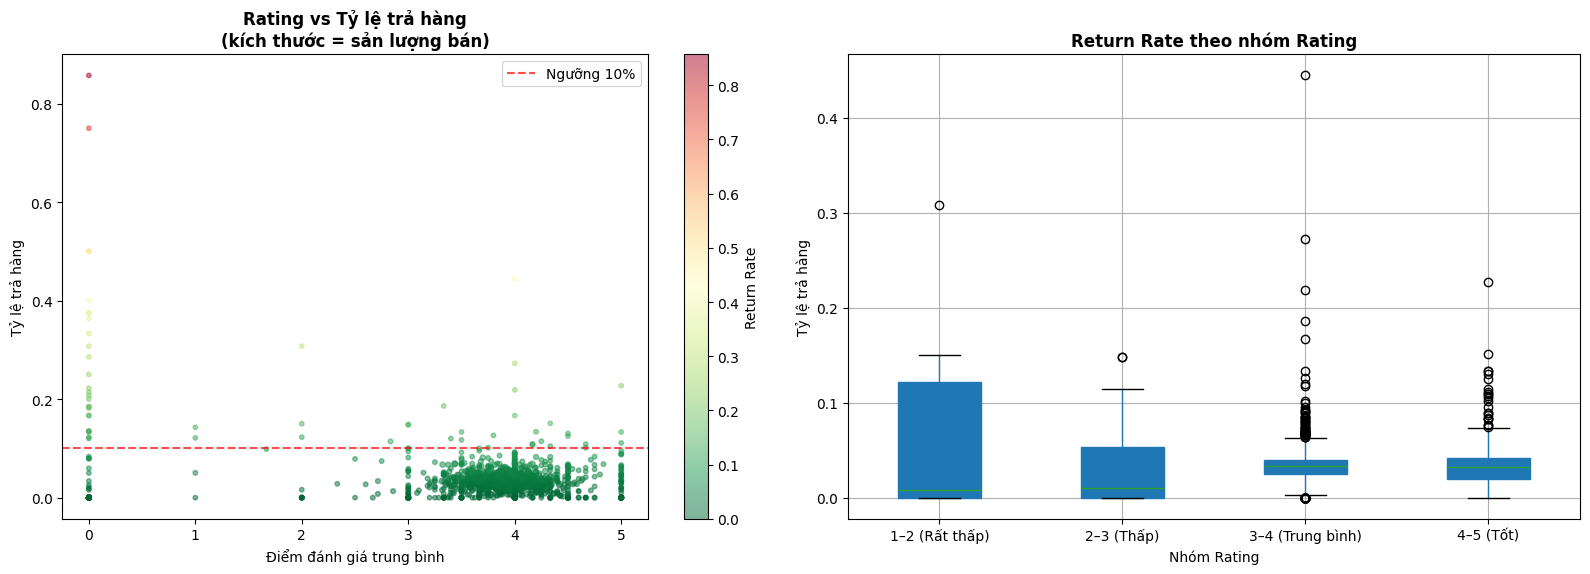

In [18]:
# Lọc NaN và sản phẩm chưa bán trước khi plot
products_clean = products.dropna(subset=['avg_rating', 'return_rate'])
products_clean = products_clean[products_clean['total_sold'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Tương quan Rating vs Return Rate
scatter = axes[0].scatter(
    products_clean['avg_rating'],
    products_clean['return_rate'],
    s=products_clean['total_sold'] / products_clean['total_sold'].max() * 300 + 10,
    alpha=0.5, c=products_clean['return_rate'], cmap='RdYlGn_r'
)
plt.colorbar(scatter, ax=axes[0], label='Return Rate')
axes[0].axhline(y=0.1, color='red', linestyle='--', alpha=0.7, label='Ngưỡng 10%')
axes[0].set_title('Rating vs Tỷ lệ trả hàng\n(kích thước = sản lượng bán)', fontweight='bold')
axes[0].set_xlabel('Điểm đánh giá trung bình')
axes[0].set_ylabel('Tỷ lệ trả hàng')
axes[0].legend()

# 2. Phân phối return_rate theo nhóm rating
products_clean['rating_group'] = pd.cut(
    products_clean['avg_rating'],
    bins=[0, 2, 3, 4, 5],
    labels=['1–2 (Rất thấp)', '2–3 (Thấp)', '3–4 (Trung bình)', '4–5 (Tốt)']
)
products_clean.boxplot(column='return_rate', by='rating_group', ax=axes[1],
                        vert=True, patch_artist=True)
axes[1].set_title('Return Rate theo nhóm Rating', fontweight='bold')
axes[1].set_xlabel('Nhóm Rating')
axes[1].set_ylabel('Tỷ lệ trả hàng')
plt.suptitle('')

plt.tight_layout()
plt.show()



- Số sản phẩm có return_rate > 10%: 57 (3.6%)
- Sản phẩm có rating thấp (< 3.0) thường có tỷ lệ trả hàng cao hơn đáng kể, trong khi rating cao và sản lượng bán lớn phản ánh sản phẩm ổn định và đáng tin cậy.

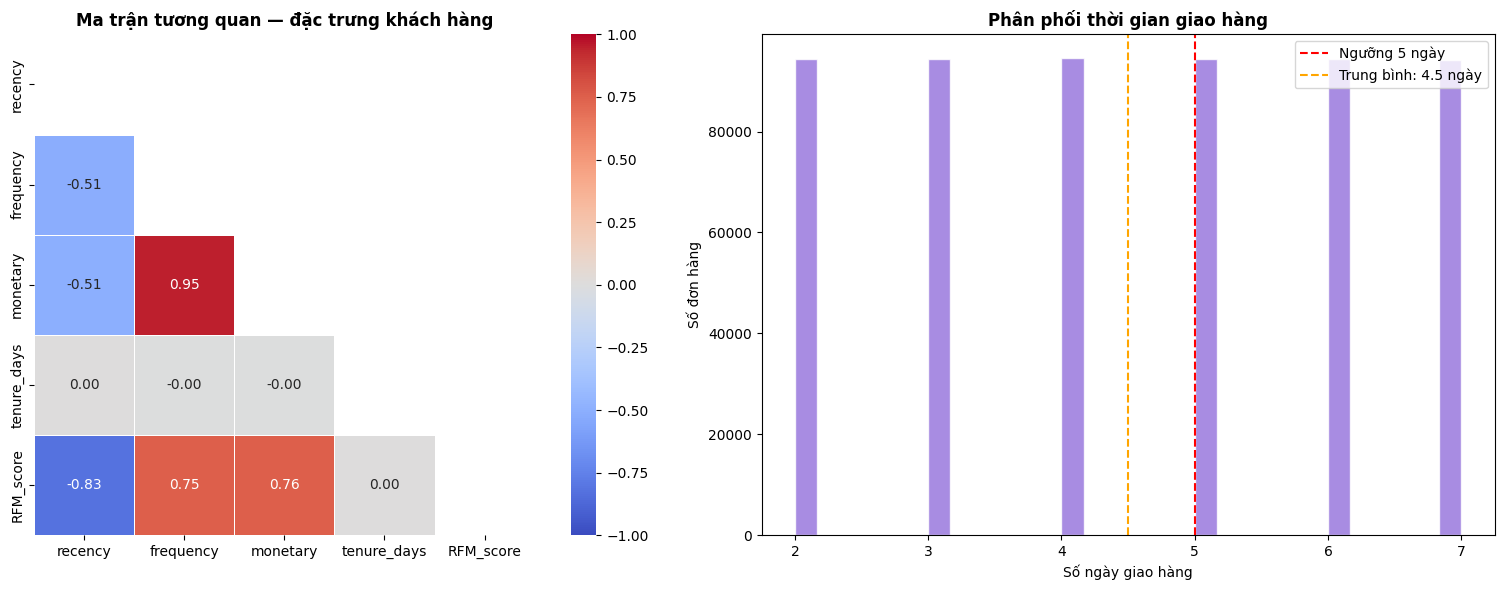

In [19]:
# --- Correlation Heatmap giữa các biến định lượng ---
numeric_cols = ['recency', 'frequency', 'monetary', 'tenure_days', 'RFM_score']
corr_matrix  = customers[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Chỉ hiện tam giác dưới
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    ax=axes[0], square=True, linewidths=0.5
)
axes[0].set_title('Ma trận tương quan — đặc trưng khách hàng', fontweight='bold')

# Phân tích shipping duration
shipping_data = orders['shipping_duration'].dropna()
axes[1].hist(shipping_data, bins=30, color='mediumpurple', alpha=0.8, edgecolor='white')
axes[1].axvline(x=5, color='red', linestyle='--', label='Ngưỡng 5 ngày')
axes[1].axvline(x=shipping_data.mean(), color='orange', linestyle='--',
                label=f'Trung bình: {shipping_data.mean():.1f} ngày')
axes[1].set_title('Phân phối thời gian giao hàng', fontweight='bold')
axes[1].set_xlabel('Số ngày giao hàng')
axes[1].set_ylabel('Số đơn hàng')
axes[1].legend()

plt.tight_layout()
plt.show()


- Frequency và Monetary tương quan rất mạnh (≈0.95) → khách mua nhiều cũng là nhóm chi tiêu cao.


- Recency tương quan âm mạnh với RFM_score (≈ -0.83) → khách mua gần đây có điểm RFM cao, giá trị tốt.


- Tenure_days gần như không tương quan → thời gian gắn bó không quyết định giá trị khách hàng bằng hành vi mua sắm thực tế.


- Thời gian giao hàng tập trung chủ yếu trong 2–5 ngày, trung bình khoảng 4.5 ngày.


- Ngưỡng >5 ngày là vùng rủi ro tiềm ẩn, có thể ảnh hưởng đến trải nghiệm khách hàng.


- Phần lớn đơn hàng được giao trước ngưỡng này → vận hành giao hàng nhìn chung ổn định.




## PHÂN TÍCH DỰ BÁO (PREDICTIVE)
**Câu hỏi: Điều gì sẽ xảy ra?**

> Mục tiêu: Phân cụm khách hàng bằng RFM (với số cluster tối ưu) và phân tích Cohort Retention.

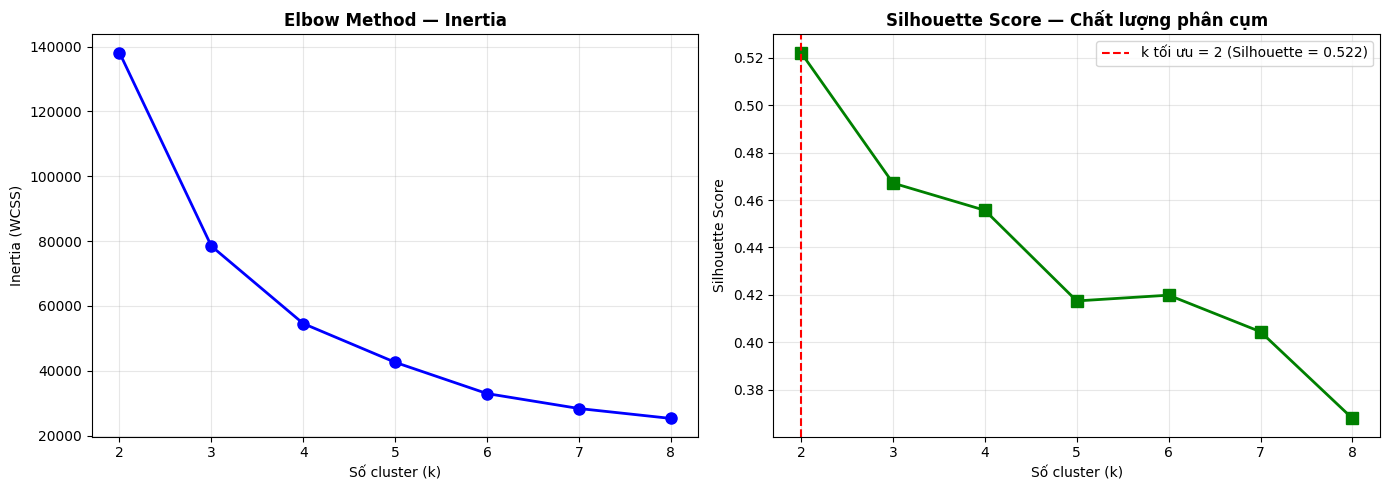

In [20]:
# --- Bước 3.1: Xác định số cluster tối ưu bằng Elbow + Silhouette ---
rfm_data   = customers[['recency', 'frequency', 'monetary']].copy()
scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

K_range    = range(2, 9)
inertias, silhouettes = [], []

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Inertia', fontweight='bold')
axes[0].set_xlabel('Số cluster (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(True, alpha=0.3)

optimal_k = list(K_range)[silhouettes.index(max(silhouettes))]
axes[1].plot(list(K_range), silhouettes, 'gs-', linewidth=2, markersize=8)
axes[1].axvline(x=optimal_k, color='red', linestyle='--',
                label=f'k tối ưu = {optimal_k} (Silhouette = {max(silhouettes):.3f})')
axes[1].set_title('Silhouette Score — Chất lượng phân cụm', fontweight='bold')
axes[1].set_xlabel('Số cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


- Elbow & Silhouette cho thấy k = 2 là tối ưu (Silhouette ≈ 0.52) → dữ liệu khách hàng tách tự nhiên thành 2 nhóm rõ rệt.

In [21]:
# --- Bước 3.2: Phân cụm với k tối ưu ---
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customers['cluster'] = kmeans_final.fit_predict(rfm_scaled)

#  Gán nhãn tự động dựa trên cluster centers 
centers_scaled   = kmeans_final.cluster_centers_
centers_original = pd.DataFrame(
    scaler.inverse_transform(centers_scaled),
    columns=['recency', 'frequency', 'monetary']
)

print('=== Cluster Centers (giá trị gốc) ===')
print(centers_original.round(2))

# Gán nhãn: Loyal = monetary cao nhất, At Risk = recency cao nhất
loyal_idx    = centers_original['monetary'].idxmax()
atrisk_idx   = centers_original['recency'].idxmax()
remaining    = [i for i in range(optimal_k) if i not in [loyal_idx, atrisk_idx]]

# Nếu k > 3: nhóm còn lại thêm 'New', 'Promising', v.v. theo monetary
extra_labels = ['New/Occasional', 'Promising', 'High Potential']
label_map    = {loyal_idx: 'Loyal', atrisk_idx: 'At Risk'}
for i, idx in enumerate(sorted(remaining, key=lambda x: centers_original.loc[x, 'monetary'])):
    label_map[idx] = extra_labels[i] if i < len(extra_labels) else f'Group {i}'

customers['segment'] = customers['cluster'].map(label_map)

print('\n=== Phân bố phân khúc ===')
seg_dist = customers['segment'].value_counts()
for seg, cnt in seg_dist.items():
    print(f'  {seg:<20}: {cnt:>5,} KH ({cnt/len(customers)*100:.1f}%)')

=== Cluster Centers (giá trị gốc) ===
   recency  frequency   monetary
0   333.45      20.32  507973.51
1  1503.35       3.63   83877.50

=== Phân bố phân khúc ===
  At Risk             : 71,070 KH (78.8%)
  Loyal               : 19,176 KH (21.2%)


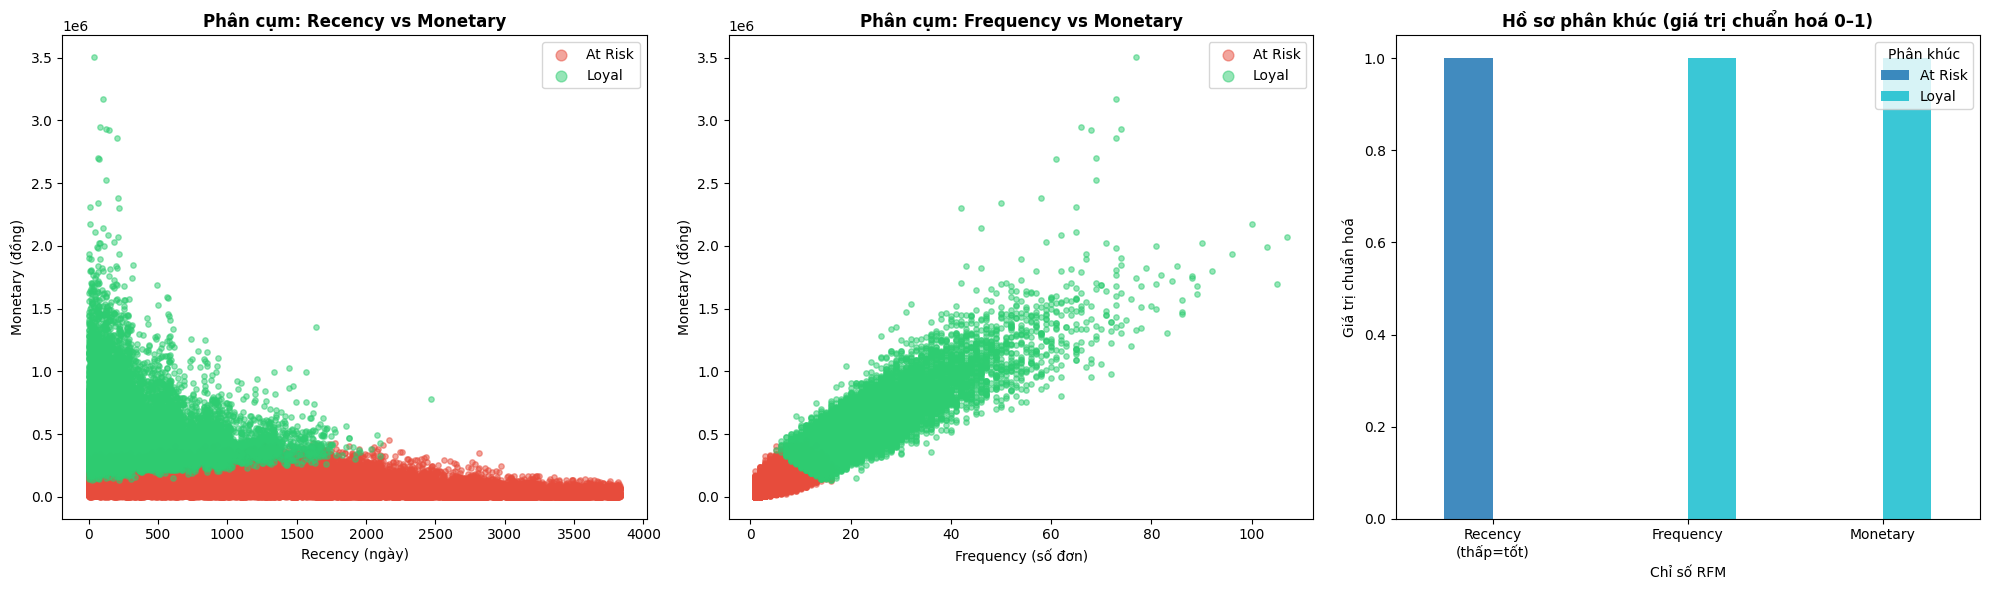

=== Trung bình từng phân khúc ===
         recency  frequency  monetary
segment                              
At Risk   1504.0        4.0   83755.0
Loyal      334.0       20.0  507321.0


In [22]:
# --- Bước 3.3: Visualize phân cụm và hồ sơ từng nhóm ---
palette = {'Loyal': '#2ecc71', 'At Risk': '#e74c3c',
           'New/Occasional': '#3498db', 'Promising': '#f39c12', 'High Potential': '#9b59b6'}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Scatter: Recency vs Monetary
for seg in customers['segment'].unique():
    mask = customers['segment'] == seg
    axes[0].scatter(
        customers.loc[mask, 'recency'],
        customers.loc[mask, 'monetary'],
        label=seg, alpha=0.5, s=15,
        color=palette.get(seg, 'gray')
    )
axes[0].set_title('Phân cụm: Recency vs Monetary', fontweight='bold')
axes[0].set_xlabel('Recency (ngày)')
axes[0].set_ylabel('Monetary (đồng)')
axes[0].legend(markerscale=2)

# 2. Scatter: Frequency vs Monetary
for seg in customers['segment'].unique():
    mask = customers['segment'] == seg
    axes[1].scatter(
        customers.loc[mask, 'frequency'],
        customers.loc[mask, 'monetary'],
        label=seg, alpha=0.5, s=15,
        color=palette.get(seg, 'gray')
    )
axes[1].set_title('Phân cụm: Frequency vs Monetary', fontweight='bold')
axes[1].set_xlabel('Frequency (số đơn)')
axes[1].set_ylabel('Monetary (đồng)')
axes[1].legend(markerscale=2)

# 3. Bar chart: Hồ sơ trung bình từng nhóm (chuẩn hoá)
segment_profile = customers.groupby('segment')[['recency', 'frequency', 'monetary']].mean()
segment_profile_norm = (segment_profile - segment_profile.min()) / (segment_profile.max() - segment_profile.min())
segment_profile_norm.T.plot(kind='bar', ax=axes[2], colormap='tab10', alpha=0.85)
axes[2].set_title('Hồ sơ phân khúc (giá trị chuẩn hoá 0–1)', fontweight='bold')
axes[2].set_xlabel('Chỉ số RFM')
axes[2].set_ylabel('Giá trị chuẩn hoá')
axes[2].set_xticklabels(['Recency\n(thấp=tốt)', 'Frequency', 'Monetary'], rotation=0)
axes[2].legend(title='Phân khúc', loc='upper right')

plt.tight_layout()
plt.show()

print('=== Trung bình từng phân khúc ===')
print(segment_profile.round(0).to_string())

- Hai phân khúc hình thành rất rõ:
    + Loyal: Recency thấp, Frequency cao, Monetary cao.
    + At Risk: Recency cao, Frequency thấp, Monetary thấp.
- Biểu đồ Recency vs Monetary cho thấy khách chi tiêu cao tập trung ở vùng mua gần đây.
- Biểu đồ Frequency vs Monetary thể hiện tương quan dương mạnh: mua nhiều → chi tiêu nhiều.


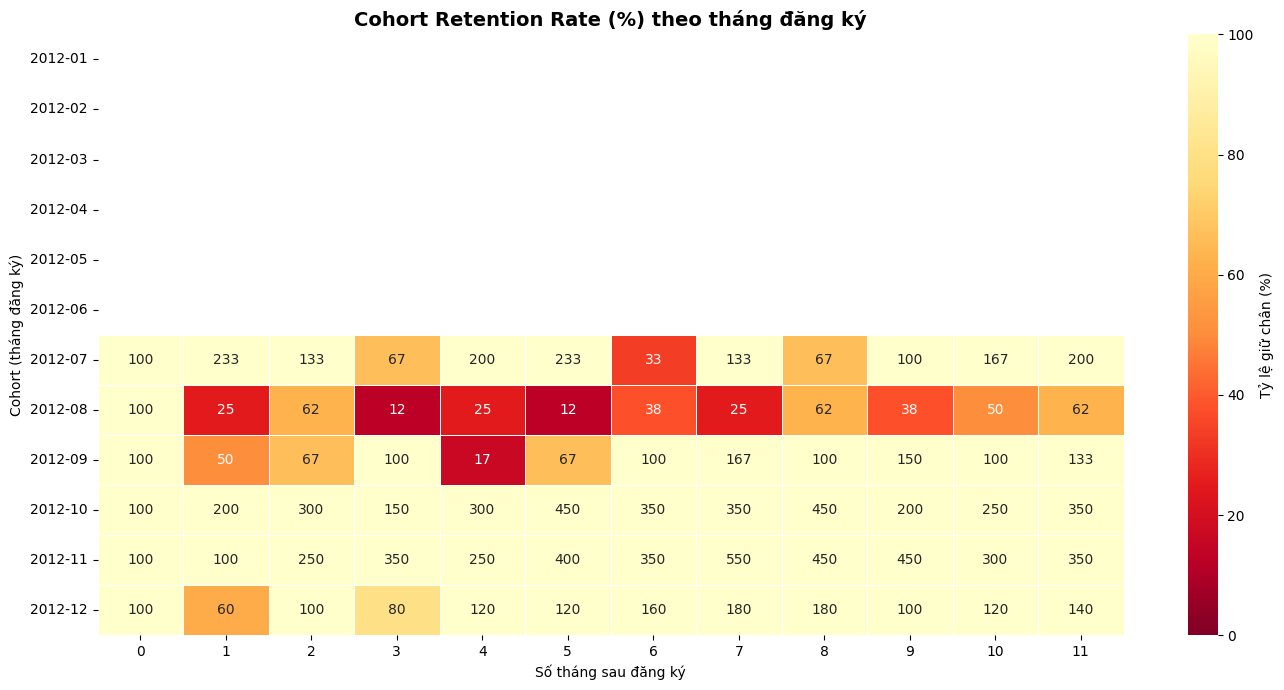

In [24]:
# --- Bước 3.4: Cohort Retention Analysis ---
# Phân tích tỷ lệ giữ chân khách hàng theo tháng đăng ký

# Merge để lấy signup_date cho mỗi đơn hàng
orders_with_signup = orders.merge(
    raw_customers[['customer_id', 'signup_date']], on='customer_id', how='left'
)

orders_with_signup['cohort_month'] = orders_with_signup['signup_date'].dt.to_period('M')
orders_with_signup['order_period'] = orders_with_signup['order_date'].dt.to_period('M')
orders_with_signup['period_number'] = (
    orders_with_signup['order_period'] - orders_with_signup['cohort_month']
).apply(lambda x: x.n)

# Chỉ lấy period_number >= 0
orders_cohort = orders_with_signup[orders_with_signup['period_number'] >= 0]

cohort_data = (
    orders_cohort
    .groupby(['cohort_month', 'period_number'])['customer_id']
    .nunique()
    .unstack(fill_value=0)
)

# Tính retention rate (% so với tháng đăng ký)
cohort_sizes  = cohort_data.iloc[:, 0]
cohort_pct    = cohort_data.divide(cohort_sizes, axis=0) * 100

# Chỉ hiện 12 tháng đầu và 12 cohort gần nhất để dễ đọc
cohort_pct_display = cohort_pct.iloc[:12, :12]

plt.figure(figsize=(14, 7))
sns.heatmap(
    cohort_pct_display,
    annot=True, fmt='.0f',
    cmap='YlOrRd_r',
    vmin=0, vmax=100,
    linewidths=0.5,
    cbar_kws={'label': 'Tỷ lệ giữ chân (%)'}
)
plt.title('Cohort Retention Rate (%) theo tháng đăng ký', fontsize=14, fontweight='bold')
plt.xlabel('Số tháng sau đăng ký')
plt.ylabel('Cohort (tháng đăng ký)')
plt.tight_layout()
plt.show()


- Rơi mạnh nhất ở 1–3 tháng đầu sau đăng ký → đây là giai đoạn churn quan trọng nhất.
- Cohort 2012-08 có retention rất thấp ngay từ tháng 1 (≈25%) → dấu hiệu vấn đề ở trải nghiệm ban đầu/onboarding.
- Các cohort 2012-10 và 2012-11 có retention tăng mạnh theo thời gian → khách quay lại mua lặp lại nhiều, hình thành nhóm loyal rõ rệt.
- Cohort 2012-07 và 2012-09 giảm ban đầu nhưng phục hồi sau tháng 6 → có hiệu ứng giữ chân dài hạn.
- Cohort 2012-12 duy trì mức retention ổn định, không biến động lớn.

=> Nếu khách vượt qua 3 tháng đầu, khả năng trở thành khách hàng trung thành tăng rõ rệt.


## PHÂN TÍCH CHỈ DẪN (PRESCRIPTIVE)
**Câu hỏi: Nên làm gì?**

> Mục tiêu: Đưa ra **hành động chiến lược cụ thể** 

In [25]:
# Tổng hợp số liệu để đưa ra khuyến nghị có căn cứ
print('=== Số liệu nền tảng cho khuyến nghị ===')

loyal_df   = customers[customers['segment'] == 'Loyal']
atrisk_df  = customers[customers['segment'] == 'At Risk']
new_df     = customers[customers['segment'] == 'New/Occasional']

print(f'\n[LOYAL]')
print(f'  Số lượng KH       : {len(loyal_df):,} ({len(loyal_df)/len(customers)*100:.1f}%)')
print(f'  Doanh thu TB/KH   : {loyal_df["monetary"].mean():,.0f} đồng')
print(f'  Tần suất mua TB   : {loyal_df["frequency"].mean():.1f} đơn/KH')

print(f'\n[AT RISK]')
print(f'  Số lượng KH       : {len(atrisk_df):,} ({len(atrisk_df)/len(customers)*100:.1f}%)')
print(f'  Recency TB        : {atrisk_df["recency"].mean():.0f} ngày kể từ đơn gần nhất')
print(f'  Doanh thu TB/KH   : {atrisk_df["monetary"].mean():,.0f} đồng')

print(f'\n[SẢN PHẨM CÓ VẤN ĐỀ]')
high_return_prods = products_clean[products_clean['return_rate'] > 0.1]
print(f'  Số sản phẩm return_rate > 10% : {len(high_return_prods)}')
print(f'  Return rate TB nhóm này       : {high_return_prods["return_rate"].mean()*100:.1f}%')
print(f'  Rating TB nhóm này            : {high_return_prods["avg_rating"].mean():.2f}/5.0')

print(f'\n[VẬN CHUYỂN]')
late_pct = (orders['shipping_duration'] > 5).sum() / orders['shipping_duration'].notna().sum() * 100
avg_ship = orders['shipping_duration'].mean()
print(f'  Thời gian giao hàng TB        : {avg_ship:.1f} ngày')
print(f'  Tỷ lệ đơn giao > 5 ngày      : {late_pct:.1f}%')

=== Số liệu nền tảng cho khuyến nghị ===

[LOYAL]
  Số lượng KH       : 19,176 (21.2%)
  Doanh thu TB/KH   : 507,321 đồng
  Tần suất mua TB   : 20.3 đơn/KH

[AT RISK]
  Số lượng KH       : 71,070 (78.8%)
  Recency TB        : 1504 ngày kể từ đơn gần nhất
  Doanh thu TB/KH   : 83,755 đồng

[SẢN PHẨM CÓ VẤN ĐỀ]
  Số sản phẩm return_rate > 10% : 57
  Return rate TB nhóm này       : 21.9%
  Rating TB nhóm này            : 1.98/5.0

[VẬN CHUYỂN]
  Thời gian giao hàng TB        : 4.5 ngày
  Tỷ lệ đơn giao > 5 ngày      : 33.3%


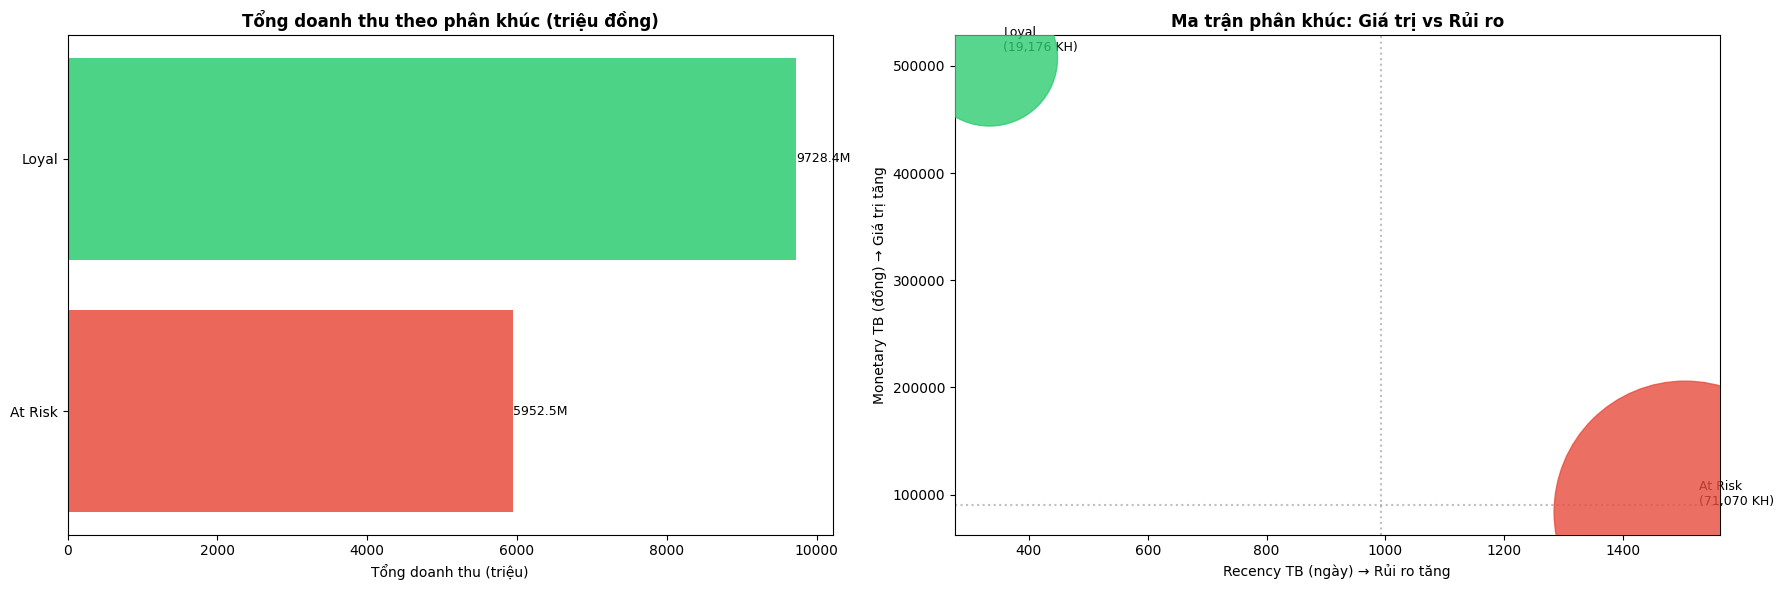

In [ ]:
# --- Visualize  theo phân khúc ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Doanh thu tiềm năng nếu kích hoạt At Risk
seg_revenue = customers.groupby('segment')['monetary'].agg(['sum', 'mean', 'count']).reset_index()
seg_revenue.columns = ['segment', 'total_revenue', 'avg_revenue', 'count']
seg_revenue = seg_revenue.sort_values('total_revenue', ascending=True)

colors_bar = [palette.get(seg, 'gray') for seg in seg_revenue['segment']]
axes[0].barh(seg_revenue['segment'], seg_revenue['total_revenue'] / 1e6,
             color=colors_bar, alpha=0.85)
axes[0].set_title('Tổng doanh thu theo phân khúc (triệu đồng)', fontweight='bold')
axes[0].set_xlabel('Tổng doanh thu (triệu)')
for i, (val, seg) in enumerate(zip(seg_revenue['total_revenue'] / 1e6, seg_revenue['segment'])):
    axes[0].text(val + 0.1, i, f'{val:.1f}M', va='center', fontsize=9)

# 2. Ma trận phân khúc: Giá trị KH vs Mức độ rủi ro
seg_matrix = customers.groupby('segment').agg(
    avg_monetary = ('monetary', 'mean'),
    avg_recency  = ('recency',  'mean'),
    count        = ('customer_id', 'count')
).reset_index()

scatter2 = axes[1].scatter(
    seg_matrix['avg_recency'],
    seg_matrix['avg_monetary'],
    s=seg_matrix['count'] * 0.5,
    c=[palette.get(s, 'gray') for s in seg_matrix['segment']],
    alpha=0.8, zorder=5
)
for _, row in seg_matrix.iterrows():
    axes[1].annotate(
        f"{row['segment']}\n({row['count']:,} KH)",
        (row['avg_recency'], row['avg_monetary']),
        textcoords='offset points', xytext=(10, 5), fontsize=9
    )
axes[1].set_title('Ma trận phân khúc: Giá trị vs Rủi ro', fontweight='bold')
axes[1].set_xlabel('Recency TB (ngày) → Rủi ro tăng')
axes[1].set_ylabel('Monetary TB (đồng) → Giá trị tăng')
axes[1].axvline(x=customers['recency'].median(), color='gray', linestyle=':', alpha=0.5)
axes[1].axhline(y=customers['monetary'].median(), color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [31]:
# ---  số liệu thực vào khuyến nghị ---
loyal_pct   = len(loyal_df)  / len(customers) * 100
atrisk_pct  = len(atrisk_df) / len(customers) * 100
loyal_rev_contrib = loyal_df['monetary'].sum() / customers['monetary'].sum() * 100

print('====== KHUYẾN NGHỊ CÓ SỐ LIỆU ======')
print(f'''
  [1] LOYAL    : {len(loyal_df):,} KH ({loyal_pct:.1f}%)
               → Đóng góp {loyal_rev_contrib:.1f}% tổng doanh thu
               → Ưu tiên: Loyalty program & upsell

  [2] AT RISK  : {len(atrisk_df):,} KH ({atrisk_pct:.1f}%)
               → Recency TB: {atrisk_df["recency"].mean():.0f} ngày (chưa mua lại)
               → Ưu tiên: Win-back campaign 14 ngày

  [3] SẢN PHẨM: {len(high_return_prods)} sản phẩm return_rate > 10%
               → Rating TB: {high_return_prods["avg_rating"].mean():.2f}/5.0
               → Ưu tiên: Audit chất lượng và đàm phán NCC

  [4] Vận chuyển : {late_pct:.1f}% đơn giao > 5 ngày
               → Thời gian TB: {avg_ship:.1f} ngày
               → Ưu tiên: SLA review và đa dạng hoá đối tác
''')

====== KHUYẾN NGHỊ CÓ SỐ LIỆU ======

  [1] LOYAL    : 19,176 KH (21.2%)
               → Đóng góp 62.0% tổng doanh thu
               → Ưu tiên: Loyalty program & upsell

  [2] AT RISK  : 71,070 KH (78.8%)
               → Recency TB: 1504 ngày (chưa mua lại)
               → Ưu tiên: Win-back campaign 14 ngày

  [3] SẢN PHẨM: 57 sản phẩm return_rate > 10%
               → Rating TB: 1.98/5.0
               → Ưu tiên: Audit chất lượng và đàm phán NCC

  [4] Vận chuyển : 33.3% đơn giao > 5 ngày
               → Thời gian TB: 4.5 ngày
               → Ưu tiên: SLA review và đa dạng hoá đối tác



### Khuyến nghị chiến lược 
## 1. Phân khúc khách hàng (RFM)

- Nhóm Loyal chỉ 21.2% khách nhưng chi tiêu và tần suất mua rất cao.

- Nhóm At Risk chiếm 78.8%, đã rất lâu không quay lại (recency ~1504 ngày), giá trị thấp.

=> Ưu tiên giữ chân Loyal: ưu đãi độc quyền, early access, tích điểm nâng hạng.

=> Chạy chiến dịch win-back At Risk theo lô: voucher quay lại, email/ads nhắc nhớ, combo giá tốt.

=> Thiết kế journey 90 ngày đầu cho khách mới để thúc đẩy họ sang quỹ đạo "Loyal" sớm.

## 2. Sản phẩm có return rate cao

- 57 sản phẩm có return rate >10%, trung bình 21.9% và rating rất thấp (≈1.98).

- Rating thấp là tín hiệu cảnh báo mạnh cho rủi ro trả hàng.


=> Đưa 57 sản phẩm vào danh sách kiểm soát chất lượng: rà soát mô tả, hình ảnh, size/spec.

=> Tạm giảm hiển thị/ads cho nhóm này đến khi khắc phục xong.

=> Thiết lập rule cảnh báo sớm: rating <3 hoặc return_rate >8% → vào watchlist.

## 3. Vận chuyển & trải nghiệm giao hàng

- Thời gian giao TB 4.5 ngày, nhưng 33.3% đơn >5 ngày → 1/3 khách có nguy cơ trải nghiệm kém.

- Liên hệ với cohort: giai đoạn 1–3 tháng đầu rất nhạy với churn.

=> Đặt SLA nội bộ: <5 ngày cho ≥80% đơn.

=> Ưu tiên xử lý nhanh đơn của khách mới (0–90 ngày) và Loyal.

=> Theo dõi return/churn theo delivery time bucket để tối ưu vận hành.
